# CT118-3-3 ODL — Assignment 2
## Deep Learning Model Building, Tuning & Evaluation
### Used-Car Price Prediction (Craigslist Used Cars Dataset)

This notebook implements **Assignment 2 (Tasks 1–4)**, building on the data preparation
performed in `eda.ipynb` and `data_cleaning.ipynb`.

**Problem framing.** This is a **supervised regression** problem: predict a used car's
listed `price` (a continuous value) from its attributes (age, mileage, manufacturer,
fuel type, condition, …). The cleaned dataset is medium-to-large scale (~340k rows after
outlier removal), dominated by **high-cardinality categorical** features — the regime where
modern tabular deep-learning architectures are most useful.

**Two deep-learning algorithms** (selected and justified in Assignment 1 — Task 1):

| Model | Architecture | Why it suits this dataset |
|-------|-------------|---------------------------|
| **Model 1 — Entity-Embedding MLP** | Learned embeddings for each categorical column, concatenated with scaled numerics, fed to a fully-connected network. | The canonical deep approach for tabular data with many categories (Guo & Berkhahn, 2016). Embeddings learn a dense representation of `manufacturer`, `model`, `region`, etc., capturing similarity that one-hot encoding cannot. |
| **Model 2 — Wide & Deep** | A *deep* path (embeddings → MLP) for generalisation, run **in parallel** with a *wide* linear path for memorisation, jointly trained (Cheng et al., 2016). | Used-car pricing has both smooth trends (age↓ → price↓) **and** sharp exception rules (e.g. `title_status=salvage` slashes value). The wide path memorises these rule-like interactions while the deep path generalises. |

**Workflow:** load cleaned data → feature engineering & encoding → train/validation/test split →
build & train both models (baseline) → hyperparameter tuning with **Keras Tuner** (~25 trials each) →
evaluate on the held-out test set → **before-vs-after-tuning comparison**.


> **About the embedded outputs.** The cell outputs saved in this notebook come from a reduced **development run** (smaller tuning budget) used to verify the pipeline executes end-to-end. For your submission, run all cells on the **full** `dataset/vehicles_cleaned.csv` with the configured `TUNER_TRIALS = 25` — the structure, tables, and plots will populate with your final numbers. Expect the full run to take noticeably longer (tuning trains many models).

## 0. Environment & Imports

We use **TensorFlow / Keras** for the models and **Keras Tuner** for hyperparameter
optimisation, as recommended in the assignment brief. A fixed random seed is set for
reproducibility.

> **Note on `keras.metrics` / `keras.losses` objects.** In Keras 3.x we pass *objects*
> (`MeanSquaredError()`, `MeanAbsoluteError()`) rather than the string shorthands
> (`'mse'`, `'mae'`) when compiling, which avoids a known dtype-promotion bug in the
> string-keyed metric container.


In [2]:
import os, warnings, time, json
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # silence TF info/warning logs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
keras = tf.keras
layers = tf.keras.layers
import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)



## 1. Configuration & Load Cleaned Data

We load `vehicles_cleaned.csv` produced by `data_cleaning.ipynb`. Key knobs:

- `SAMPLE_SIZE` — set to an integer (e.g. `100_000`) for fast development runs, or `None`
  to train on the **full** cleaned dataset (the default for the final submission).
- `TUNER_TRIALS` — number of Keras Tuner trials per model.
- `MAX_EPOCHS` / `BATCH_SIZE` — training budget; EarlyStopping ends runs sooner when
  validation loss stops improving.


In [3]:
# ── CONFIG ────────────────────────────────────────────────────────────────
DATA_PATH    = os.path.join('dataset', 'vehicles_cleaned.csv')
SAMPLE_SIZE  = None        # None = full dataset; or e.g. 100_000 for fast dev
TUNER_TRIALS = 25          # Keras Tuner trials per model (assignment: ~25-30)
MAX_EPOCHS   = 60          # upper bound; EarlyStopping usually stops earlier
TUNE_EPOCHS  = 25          # shorter budget per tuning trial
BATCH_SIZE   = 512
TARGET       = 'price'

df = pd.read_csv(DATA_PATH)
if SAMPLE_SIZE is not None:
    df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)

print(f'Loaded cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} cols')
df.head(3)

Loaded cleaned dataset: 340,224 rows x 20 cols


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,description,state,lat,long,posting_date
0,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,unknown,unknown,pickup,white,Carvana is the safer way to buy a car During t...,al,32.59,-85.48,2021-05-04T12:31:18-0500
1,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,unknown,unknown,pickup,blue,Carvana is the safer way to buy a car During t...,al,32.59,-85.48,2021-05-04T12:31:08-0500
2,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,unknown,unknown,pickup,red,Carvana is the safer way to buy a car During t...,al,32.59,-85.48,2021-05-04T12:31:25-0500


## 2. Feature Engineering & Selection

A few targeted steps prepare the cleaned data specifically for the neural networks:

1. **`car_age`** — derived as `(max posting year) − year`. Age is a stronger, more linear
   predictor of price than the raw calendar `year`, and it generalises to future data.
2. **Drop free-text / identifier columns** — `description` (unstructured text, out of scope
   for these tabular models), `posting_date` (already distilled into `car_age`), and `model`
   (extremely high cardinality with a long tail; `manufacturer` carries the useful signal
   while keeping the embedding tractable). These can be revisited as future work.
3. **Log-transform the target** — `price` is right-skewed (a few expensive cars). We train on
   `log1p(price)` so the loss is not dominated by high-priced outliers, then invert with
   `expm1` for reporting in dollars. This is a standard variance-stabilising transform for
   skewed monetary targets.
4. **Split features** into **numeric** (scaled) and **categorical** (embedded).


In [4]:
# 1) car_age from posting year
df['posting_year'] = pd.to_datetime(df['posting_date'], errors='coerce', utc=True).dt.year
ref_year = int(df['posting_year'].median())          # robust reference year
df['car_age'] = (ref_year - df['year']).clip(lower=0) # no negative ages
print(f'Reference (posting) year used for age: {ref_year}')

# 2) Drop columns not used by the tabular networks
drop_cols = [c for c in ['description', 'posting_date', 'posting_year', 'model']
             if c in df.columns]
df = df.drop(columns=drop_cols)

# 3) Log-transform skewed target
df['price_log'] = np.log1p(df[TARGET])

# 4) Identify feature groups
num_feats = [c for c in ['car_age', 'odometer', 'lat', 'long'] if c in df.columns]
exclude   = set(num_feats + [TARGET, 'price_log', 'year'])
cat_feats = [c for c in df.columns
             if c not in exclude and df[c].dtype == 'object']

print(f'Numeric features  ({len(num_feats)}): {num_feats}')
print(f'Categorical feats ({len(cat_feats)}): {cat_feats}')

Reference (posting) year used for age: 2021
Numeric features  (4): ['car_age', 'odometer', 'lat', 'long']
Categorical feats (12): ['region', 'manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state']


### 2.1 Quick look at target skew (before vs after log-transform)
The log transform pulls in the long right tail, giving the network a better-conditioned
target to learn.

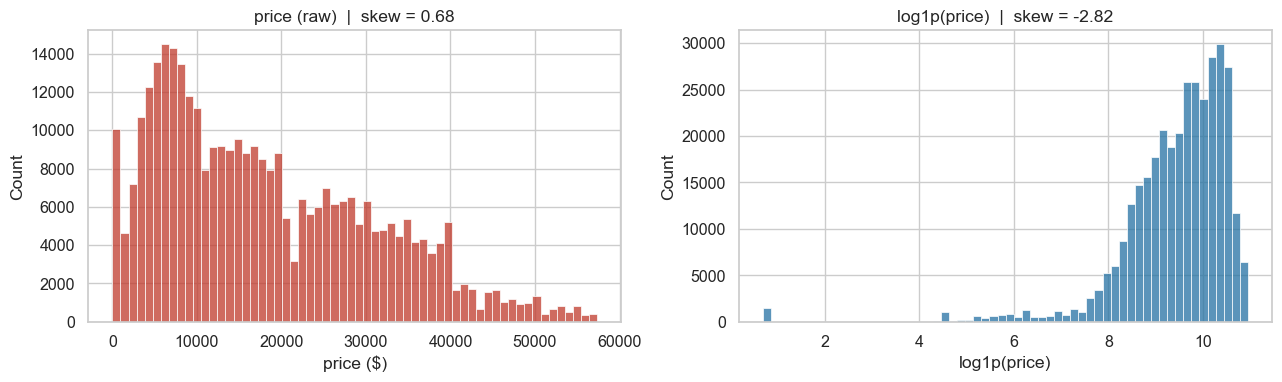

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=60, ax=axes[0], color='#c0392b')
axes[0].set_title(f'price (raw)  |  skew = {df[TARGET].skew():.2f}')
axes[0].set_xlabel('price ($)')
sns.histplot(df['price_log'], bins=60, ax=axes[1], color='#2471a3')
axes[1].set_title(f'log1p(price)  |  skew = {df["price_log"].skew():.2f}')
axes[1].set_xlabel('log1p(price)')
plt.tight_layout(); plt.show()

## 3. Train / Validation / Test Split & Encoding

We use a **three-way split** — this is essential for an honest tuning workflow:

- **Train (70%)** — fit model weights.
- **Validation (15%)** — used by EarlyStopping and by Keras Tuner to select hyperparameters.
- **Test (15%)** — **held out and never seen during training or tuning**, used only for the
  final, unbiased performance report.

**Preprocessing is fit on the training split only**, then applied to validation and test. This
prevents data leakage (the scaler's mean/variance and the encoder's category vocabulary must
not "peek" at the held-out data).

- **Numeric features** → `StandardScaler` (zero mean, unit variance) so all inputs are on a
  comparable scale for gradient descent.
- **Categorical features** → `OrdinalEncoder` to integer codes. Unseen categories at
  inference map to a dedicated index. Codes are shifted by `+1` so index `0` is reserved as a
  padding / unknown slot inside each `Embedding` layer.


In [6]:
X = df[num_feats + cat_feats].copy()
y = df['price_log'].values

# 70 / 15 / 15 split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED)

print(f'Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')

# Fit preprocessing on TRAIN ONLY
scaler = StandardScaler().fit(X_train[num_feats])
encoder = OrdinalEncoder(handle_unknown='use_encoded_value',
                         unknown_value=-1).fit(X_train[cat_feats])

def preprocess(Xframe):
    num = scaler.transform(Xframe[num_feats]).astype('float32')
    cat = (encoder.transform(Xframe[cat_feats]).astype('int64') + 1)  # +1 -> 0 reserved
    return num, cat

num_tr, cat_tr = preprocess(X_train)
num_val, cat_val = preprocess(X_val)
num_te, cat_te = preprocess(X_test)

# Embedding input dimension per categorical column (max code + 1, across all splits)
cardinalities = [
    int(max(cat_tr[:, i].max(), cat_val[:, i].max(), cat_te[:, i].max())) + 1
    for i in range(len(cat_feats))
]
for c, card in zip(cat_feats, cardinalities):
    print(f'  {c:15s} -> embedding input dim {card}')

Train: 238,156 | Val: 51,034 | Test: 51,034
  region          -> embedding input dim 405
  manufacturer    -> embedding input dim 41
  condition       -> embedding input dim 8
  cylinders       -> embedding input dim 10
  fuel            -> embedding input dim 6
  title_status    -> embedding input dim 7
  transmission    -> embedding input dim 4
  drive           -> embedding input dim 5
  size            -> embedding input dim 6
  type            -> embedding input dim 15
  paint_color     -> embedding input dim 14
  state           -> embedding input dim 52


### 3.1 Pack inputs for multi-input Keras models
Both networks take **one numeric input tensor plus one integer tensor per categorical
column**. The helper below arranges each split into the list of arrays Keras expects.

In [7]:
def make_inputs(num, cat):
    '''Return [numeric_block, cat_col_0, cat_col_1, ...] for a multi-input model.'''
    return [num] + [cat[:, i] for i in range(cat.shape[1])]

train_inputs = make_inputs(num_tr, cat_tr)
val_inputs   = make_inputs(num_val, cat_val)
test_inputs  = make_inputs(num_te, cat_te)
print('Input tensors per sample:', len(train_inputs),
      '(1 numeric block +', len(cat_feats), 'categorical columns)')

Input tensors per sample: 13 (1 numeric block + 12 categorical columns)


## 4. Evaluation Metrics

The assignment asks us to select and describe our evaluation metrics. For regression we report:

- **MAE (Mean Absolute Error)** — average absolute dollar error. Easy to interpret ("on
  average we are off by \$X"); robust to outliers.
- **RMSE (Root Mean Squared Error)** — square-root of mean squared error, in dollars.
  Penalises large errors more heavily than MAE, so it surfaces big mistakes.
- **R² (Coefficient of Determination)** — fraction of price variance explained by the model
  (1.0 = perfect, 0 = no better than predicting the mean). A scale-free goodness-of-fit
  summary that is convenient for comparing models.

Because we train on `log1p(price)`, every prediction is inverted with `expm1` **before**
computing metrics, so all numbers are reported in real **dollars**.


In [8]:
def evaluate_model(model, inputs, y_log_true, label=''):
    '''Predict, invert the log-transform, and compute MAE / RMSE / R2 in dollars.'''
    pred_log = model.predict(inputs, verbose=0).ravel()
    pred  = np.expm1(pred_log)
    truth = np.expm1(y_log_true)
    mae  = mean_absolute_error(truth, pred)
    rmse = float(np.sqrt(mean_squared_error(truth, pred)))
    r2   = r2_score(truth, pred)
    if label:
        print(f'{label:32s} | MAE ${mae:>9,.0f} | RMSE ${rmse:>9,.0f} | R2 {r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Common training callback: stop when validation loss plateaus, keep best weights
def early_stop(patience=8):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience, restore_best_weights=True)

results = {}   # collects every model's test metrics for the final comparison

## 5. Model 1 — Entity-Embedding MLP (Baseline)

### Architecture
Each categorical column gets its own **`Embedding` layer** that maps an integer code to a
dense vector. We size each embedding as `min(50, round(cardinality**0.5))` — a widely-used
rule of thumb that gives small categories tiny vectors and large categories richer ones,
while capping width to control parameters. The embeddings are flattened and concatenated with
the scaled numeric block, then passed through a stack of `Dense → BatchNorm → Dropout` blocks.

- **BatchNormalization** stabilises and speeds up training by normalising layer activations.
- **Dropout** randomly zeroes activations during training to reduce overfitting.
- A single linear output neuron predicts `log1p(price)` (regression), trained with **MSE** loss.

This baseline uses sensible default hyperparameters; Section 7 tunes them.


In [9]:
def build_embedding_mlp(units=128, n_layers=2, dropout=0.2,
                        learning_rate=1e-3, emb_factor=0.5):
    # --- Inputs: one numeric block + one integer input per categorical column ---
    num_in  = keras.Input(shape=(len(num_feats),), dtype='float32', name='num')
    cat_ins = [keras.Input(shape=(1,), dtype='int64', name=f'cat_{c}') for c in cat_feats]

    # --- Entity embeddings for each categorical column ---
    emb_list = []
    for i, ci in enumerate(cat_ins):
        emb_dim = int(min(50, max(2, round(cardinalities[i] ** emb_factor))))
        e = layers.Embedding(cardinalities[i], emb_dim)(ci)
        emb_list.append(layers.Flatten()(e))

    # --- Concatenate numerics + all embeddings ---
    x = layers.Concatenate()([num_in] + emb_list)

    # --- Fully-connected body ---
    for _ in range(n_layers):
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout)(x)

    out = layers.Dense(1)(x)                  # linear output for regression
    model = keras.Model([num_in] + cat_ins, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
    return model

mlp_base = build_embedding_mlp()
mlp_base.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_region          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_manufacturer    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_condition       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_cylinders       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_fuel            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_title_status    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_transmission    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_drive           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_size            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_type            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_paint_color     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_state           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 20)     │      8,100 │ cat_region[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 6)      │        246 │ cat_manufacturer… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 3)      │         24 │ cat_condition[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 3)      │         30 │ cat_cylinders[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 2)      │         12 │ cat_fuel[0][0]  

 Total params: 34,672 (135.44 KB)

 Trainable params: 34,160 (133.44 KB)

 Non-trainable params: 512 (2.00 KB)

In [10]:
t0 = time.time()
hist_mlp_base = mlp_base.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
print(f'Trained Embedding-MLP (baseline) in {time.time()-t0:.1f}s '
      f'over {len(hist_mlp_base.history["loss"])} epochs')

results['MLP (baseline)'] = evaluate_model(
    mlp_base, test_inputs, y_test, 'MLP (baseline) — TEST')

Trained Embedding-MLP (baseline) in 841.0s over 49 epochs
MLP (baseline) — TEST            | MAE $    3,745 | RMSE $    5,835 | R2 0.7881


## 6. Model 2 — Wide & Deep (Baseline)

### Architecture
Wide & Deep (Cheng et al., 2016) trains two paths jointly:

- **Deep path** — the same entity-embedding-→-MLP idea as Model 1, giving **generalisation**
  across similar feature combinations.
- **Wide path** — a linear model over the inputs (here, a 1-dimensional embedding per
  categorical column plus the numerics) that **memorises** strong, rule-like effects (e.g.
  *salvage title ⇒ much lower price*).

Their outputs are concatenated into a final linear neuron and optimised together. This pairing
suits used-car pricing, which mixes smooth trends with sharp categorical exceptions.


In [11]:
def build_wide_deep(units=256, n_layers=3, dropout=0.3,
                    learning_rate=1e-3, emb_factor=0.5):
    num_in  = keras.Input(shape=(len(num_feats),), dtype='float32', name='num')
    cat_ins = [keras.Input(shape=(1,), dtype='int64', name=f'cat_{c}') for c in cat_feats]

    deep_embs, wide_embs = [], []
    for i, ci in enumerate(cat_ins):
        emb_dim = int(min(50, max(2, round(cardinalities[i] ** emb_factor))))
        deep_embs.append(layers.Flatten()(layers.Embedding(cardinalities[i], emb_dim)(ci)))
        wide_embs.append(layers.Flatten()(layers.Embedding(cardinalities[i], 1)(ci)))  # linear

    # Deep path: embeddings + numerics through an MLP
    deep = layers.Concatenate()([num_in] + deep_embs)
    for _ in range(n_layers):
        deep = layers.Dense(units, activation='relu')(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Dropout(dropout)(deep)

    # Wide path: linear terms (1-D embeddings + numerics)
    wide = layers.Concatenate()([num_in] + wide_embs)

    # Combine and predict
    combined = layers.Concatenate()([wide, deep])
    out = layers.Dense(1)(combined)
    model = keras.Model([num_in] + cat_ins, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=keras.losses.MeanSquaredError(),
        metrics=[keras.metrics.MeanAbsoluteError(name='mae')])
    return model

wd_base = build_wide_deep()
wd_base.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_region          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_manufacturer    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_condition       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_cylinders       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_fuel            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_title_status    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_transmission    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_drive           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_size            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_type            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_paint_color     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_state           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 1, 20)     │      8,100 │ cat_region[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 1, 6)      │        246 │ cat_manufacturer… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 1, 3)      │         24 │ cat_condition[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_18        │ (None, 1, 3)      │         30 │ cat_cylinders[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_20        │ (None, 1, 2)      │         12 │ cat_fuel[0][0]  

 Total params: 160,573 (627.24 KB)

 Trainable params: 159,037 (621.24 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [12]:
t0 = time.time()
hist_wd_base = wd_base.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
print(f'Trained Wide&Deep (baseline) in {time.time()-t0:.1f}s '
      f'over {len(hist_wd_base.history["loss"])} epochs')

results['Wide&Deep (baseline)'] = evaluate_model(
    wd_base, test_inputs, y_test, 'Wide&Deep (baseline) — TEST')

Trained Wide&Deep (baseline) in 764.8s over 60 epochs
Wide&Deep (baseline) — TEST      | MAE $    3,420 | RMSE $    5,314 | R2 0.8242


### 6.1 Baseline training curves
Validation loss tracking training loss (without a large gap) indicates the models are learning
without severe overfitting.

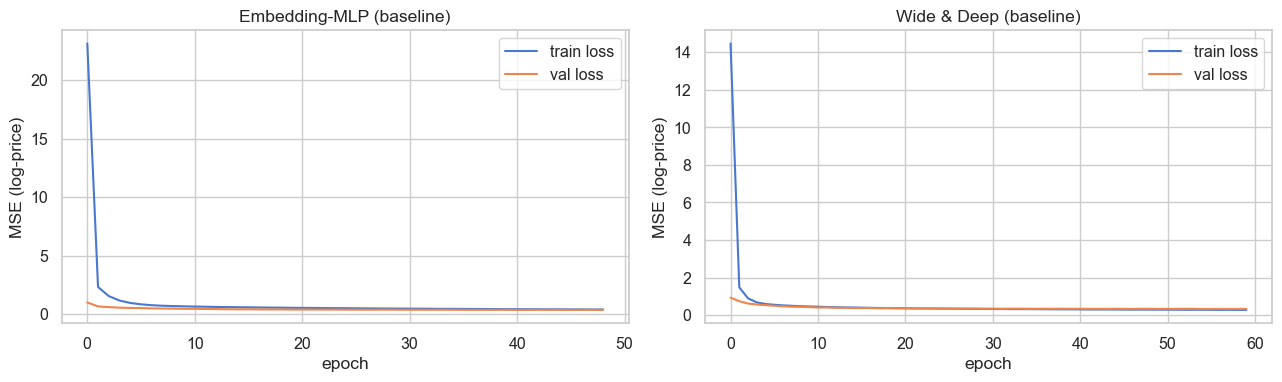

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, title in [
        (axes[0], hist_mlp_base, 'Embedding-MLP (baseline)'),
        (axes[1], hist_wd_base,  'Wide & Deep (baseline)')]:
    ax.plot(hist.history['loss'], label='train loss')
    ax.plot(hist.history['val_loss'], label='val loss')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.set_ylabel('MSE (log-price)')
    ax.legend()
plt.tight_layout(); plt.show()

## 7. Task 2 — Hyperparameter Tuning with Keras Tuner

### Hyperparameters tuned (and why they matter)

| Hyperparameter | Role |
|----------------|------|
| **units** | Width of each hidden layer. Wider → more capacity, but more overfitting risk / compute. |
| **n_layers** | Network depth. Deeper can model more complex interactions but is harder to train. |
| **dropout** | Regularisation strength; higher reduces overfitting but can underfit. |
| **learning_rate** | Adam step size; the single most impactful knob for convergence speed/quality. |
| **emb_factor** | Exponent controlling categorical embedding width (`card**emb_factor`). |

### Optimisation technique
We use **Keras Tuner's `RandomSearch`**, which samples `TUNER_TRIALS` (≈25) configurations from
the search space and keeps the one with the lowest **validation loss**. Random search is a
strong, standard baseline for hyperparameter optimisation — for a fixed budget it typically
matches or beats grid search because it does not waste trials on unimportant dimensions
(Bergstra & Bengio, 2012). Each trial trains for a shorter `TUNE_EPOCHS` budget with
EarlyStopping. *(Keras Tuner also offers `Hyperband` and `BayesianOptimization` as drop-in
alternatives.)*


In [14]:
# --- HyperModel wrappers expose the search space to Keras Tuner ---
def mlp_hypermodel(hp):
    return build_embedding_mlp(
        units=hp.Choice('units', [64, 128, 256]),
        n_layers=hp.Int('n_layers', 1, 3),
        dropout=hp.Choice('dropout', [0.1, 0.2, 0.3, 0.4]),
        learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4]),
        emb_factor=hp.Choice('emb_factor', [0.25, 0.5]))

def wide_deep_hypermodel(hp):
    return build_wide_deep(
        units=hp.Choice('units', [128, 256, 384]),
        n_layers=hp.Int('n_layers', 2, 4),
        dropout=hp.Choice('dropout', [0.2, 0.3, 0.4]),
        learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4]),
        emb_factor=hp.Choice('emb_factor', [0.25, 0.5]))

### 7.1 Tune Model 1 — Embedding-MLP

In [15]:
tuner_mlp = kt.RandomSearch(
    mlp_hypermodel,
    objective='val_loss',
    max_trials=TUNER_TRIALS,
    seed=SEED,
    overwrite=True,
    directory='kt_dir', project_name='mlp')

tuner_mlp.search(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=TUNE_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop(patience=5)], verbose=0)

best_hp_mlp = tuner_mlp.get_best_hyperparameters(1)[0]
print('Best Embedding-MLP hyperparameters:')
print(json.dumps(best_hp_mlp.values, indent=2))


Best Embedding-MLP hyperparameters:
{
  "units": 256,
  "n_layers": 3,
  "dropout": 0.1,
  "learning_rate": 0.001,
  "emb_factor": 0.25
}


In [16]:
# Retrain the best MLP config to the full epoch budget
mlp_tuned = build_embedding_mlp(**best_hp_mlp.values)
hist_mlp_tuned = mlp_tuned.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
results['MLP (tuned)'] = evaluate_model(
    mlp_tuned, test_inputs, y_test, 'MLP (tuned) — TEST')

MLP (tuned) — TEST               | MAE $    3,546 | RMSE $    5,515 | R2 0.8107


### 7.2 Tune Model 2 — Wide & Deep

In [17]:
tuner_wd = kt.RandomSearch(
    wide_deep_hypermodel,
    objective='val_loss',
    max_trials=TUNER_TRIALS,
    seed=SEED,
    overwrite=True,
    directory='kt_dir', project_name='wide_deep')

tuner_wd.search(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=TUNE_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop(patience=5)], verbose=0)

best_hp_wd = tuner_wd.get_best_hyperparameters(1)[0]
print('Best Wide & Deep hyperparameters:')
print(json.dumps(best_hp_wd.values, indent=2))

Best Wide & Deep hyperparameters:
{
  "units": 384,
  "n_layers": 4,
  "dropout": 0.2,
  "learning_rate": 0.001,
  "emb_factor": 0.25
}


In [18]:
wd_tuned = build_wide_deep(**best_hp_wd.values)
hist_wd_tuned = wd_tuned.fit(
    train_inputs, y_train,
    validation_data=(val_inputs, y_val),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop()], verbose=0)
results['Wide&Deep (tuned)'] = evaluate_model(
    wd_tuned, test_inputs, y_test, 'Wide&Deep (tuned) — TEST')

Wide&Deep (tuned) — TEST         | MAE $    3,471 | RMSE $    5,379 | R2 0.8199


## 8. Task 3 — Evaluation & Before/After-Tuning Comparison

All four models are evaluated on the **same held-out test set** (never used in training or
tuning), so the comparison is fair. The table and charts below contrast each model's
performance **before vs after** hyperparameter tuning.


In [19]:
comp = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2']]
comp = comp.loc[['MLP (baseline)', 'MLP (tuned)',
                 'Wide&Deep (baseline)', 'Wide&Deep (tuned)']]
comp_display = comp.copy()
comp_display['MAE']  = comp_display['MAE'].map('${:,.0f}'.format)
comp_display['RMSE'] = comp_display['RMSE'].map('${:,.0f}'.format)
comp_display['R2']   = comp_display['R2'].map('{:.4f}'.format)
print('TEST-SET PERFORMANCE'); print('=' * 64)
comp_display

TEST-SET PERFORMANCE


,MAE,RMSE,R2
MLP (baseline),"$3,745","$5,835",0.7881
MLP (tuned),"$3,546","$5,515",0.8107
Wide&Deep (baseline),"$3,420","$5,314",0.8242
Wide&Deep (tuned),"$3,471","$5,379",0.8199


### 8.1 Before vs after tuning — improvement summary
Positive values mean tuning **reduced error** (MAE/RMSE) or **increased** explained variance (R²).

In [20]:
def pct(before, after):  # signed % change
    return (after - before) / before * 100

summary = pd.DataFrame({
    'MLP':       {
        'MAE  ($)  before→after': f"{comp.loc['MLP (baseline)','MAE']:,.0f} → {comp.loc['MLP (tuned)','MAE']:,.0f}",
        'RMSE ($)  before→after': f"{comp.loc['MLP (baseline)','RMSE']:,.0f} → {comp.loc['MLP (tuned)','RMSE']:,.0f}",
        'R2        before→after': f"{comp.loc['MLP (baseline)','R2']:.4f} → {comp.loc['MLP (tuned)','R2']:.4f}",
        'MAE reduction (%)':      f"{-pct(comp.loc['MLP (baseline)','MAE'], comp.loc['MLP (tuned)','MAE']):.1f}%",
        'R2 gain (abs)':          f"{comp.loc['MLP (tuned)','R2'] - comp.loc['MLP (baseline)','R2']:+.4f}",
    },
    'Wide&Deep': {
        'MAE  ($)  before→after': f"{comp.loc['Wide&Deep (baseline)','MAE']:,.0f} → {comp.loc['Wide&Deep (tuned)','MAE']:,.0f}",
        'RMSE ($)  before→after': f"{comp.loc['Wide&Deep (baseline)','RMSE']:,.0f} → {comp.loc['Wide&Deep (tuned)','RMSE']:,.0f}",
        'R2        before→after': f"{comp.loc['Wide&Deep (baseline)','R2']:.4f} → {comp.loc['Wide&Deep (tuned)','R2']:.4f}",
        'MAE reduction (%)':      f"{-pct(comp.loc['Wide&Deep (baseline)','MAE'], comp.loc['Wide&Deep (tuned)','MAE']):.1f}%",
        'R2 gain (abs)':          f"{comp.loc['Wide&Deep (tuned)','R2'] - comp.loc['Wide&Deep (baseline)','R2']:+.4f}",
    },
}).T
summary

,MAE ($) before→after,RMSE ($) before→after,R2 before→after,MAE reduction (%),R2 gain (abs)
MLP,"3,745 → 3,546","5,835 → 5,515",0.7881 → 0.8107,5.3%,+0.0226
Wide&Deep,"3,420 → 3,471","5,314 → 5,379",0.8242 → 0.8199,-1.5%,-0.0043


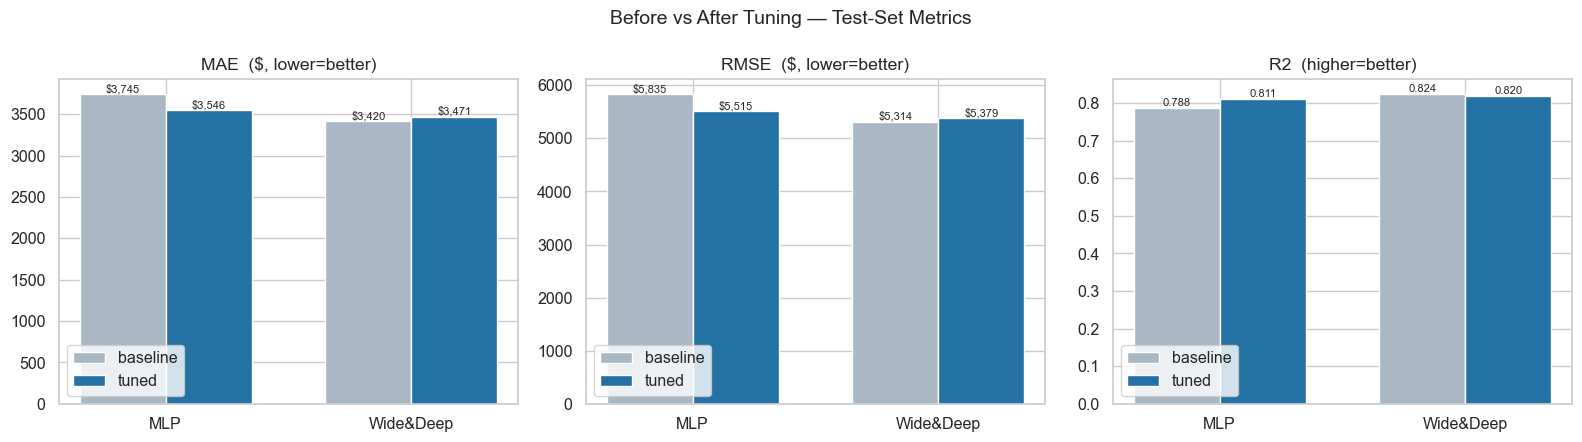

In [21]:
# --- Grouped bar charts: baseline vs tuned for each model & metric ---
models = ['MLP', 'Wide&Deep']
metrics = ['MAE', 'RMSE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = np.arange(len(models)); w = 0.35
for ax, metric in zip(axes, metrics):
    base_vals  = [comp.loc[f'{m} (baseline)', metric] for m in models]
    tuned_vals = [comp.loc[f'{m} (tuned)',    metric] for m in models]
    ax.bar(x - w/2, base_vals, w, label='baseline', color='#aab7c4')
    ax.bar(x + w/2, tuned_vals, w, label='tuned',    color='#2471a3')
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title(metric + ('  ($, lower=better)' if metric != 'R2' else '  (higher=better)'))
    ax.legend()
    for i, (b, t) in enumerate(zip(base_vals, tuned_vals)):
        fmt = '{:.3f}' if metric == 'R2' else '${:,.0f}'
        ax.text(i - w/2, b, fmt.format(b), ha='center', va='bottom', fontsize=8)
        ax.text(i + w/2, t, fmt.format(t), ha='center', va='bottom', fontsize=8)
fig.suptitle('Before vs After Tuning — Test-Set Metrics', fontsize=14)
plt.tight_layout(); plt.show()

### 8.2 Predicted vs actual price (best model)


Best model by R2: Wide&Deep (baseline)


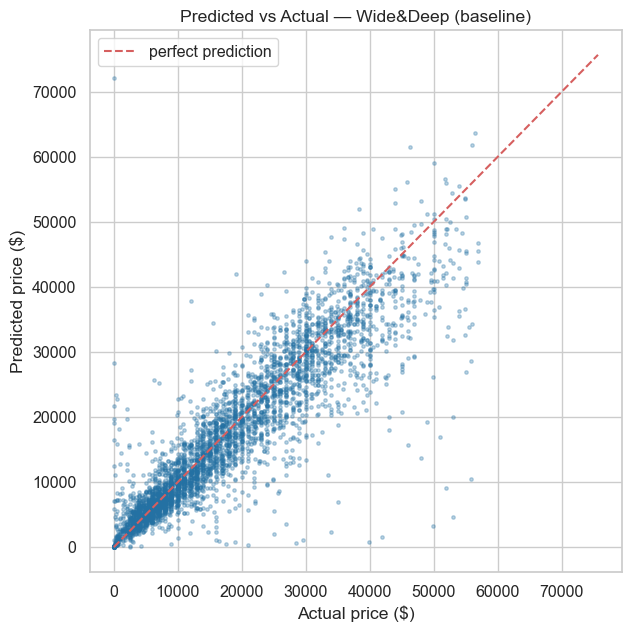

In [22]:
# Pick the best model by R2
best_name = comp['R2'].idxmax()
best_model = {'MLP (baseline)': mlp_base, 'MLP (tuned)': mlp_tuned,
              'Wide&Deep (baseline)': wd_base, 'Wide&Deep (tuned)': wd_tuned}[best_name]
print(f'Best model by R2: {best_name}')

pred = np.expm1(best_model.predict(test_inputs, verbose=0).ravel())
truth = np.expm1(y_test)
idx = np.random.choice(len(truth), size=min(4000, len(truth)), replace=False)

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(truth[idx], pred[idx], s=6, alpha=0.3, color='#2471a3')
lim = [0, max(truth.max(), pred.max())]
ax.plot(lim, lim, 'r--', lw=1.5, label='perfect prediction')
ax.set_xlabel('Actual price ($)'); ax.set_ylabel('Predicted price ($)')
ax.set_title(f'Predicted vs Actual — {best_name}')
ax.legend(); plt.tight_layout(); plt.show()